##### Copyright 2023 The MediaPipe Authors. All Rights Reserved.

In [2]:
#@title Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# https://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

# Gesture Recognizer with MediaPipe Tasks

This notebook shows you how to use MediaPipe Tasks Python API to recognize hand gestures in images.

## Preparation

Let's start with installing MediaPipe.

In [3]:
%pip install -q "numpy<2" "matplotlib<3.9" mediapipe opencv-python

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Then download an off-the-shelf model. This model can recognize 7 hand gestures: 👍, 👎, ✌️, ☝️, ✊, 👋, 🤟

Check out the [MediaPipe documentation](https://developers.google.com/mediapipe/solutions/vision/gesture_recognizer#models) for more details about the model.

In [4]:
from pathlib import Path
import shutil

MODEL_PATH = Path('gesture_recognizer.task')
LOCAL_BACKUP_MODEL = Path('../ios/GestureRecognizer/gesture_recognizer.task')

if (not MODEL_PATH.exists()) or MODEL_PATH.stat().st_size < 1_000_000:
    if LOCAL_BACKUP_MODEL.exists():
        shutil.copyfile(LOCAL_BACKUP_MODEL, MODEL_PATH)
    else:
        raise FileNotFoundError('gesture_recognizer.task was not found. Expected a local copy next to the notebook.')

print(f'Using model: {MODEL_PATH.resolve()} ({MODEL_PATH.stat().st_size:,} bytes)')


Using model: C:\Users\mjmer\OneDrive\Documents\GitHub\Gesture-Recognition\gesture_recognizer.task (8,373,440 bytes)


## Visualization Utilities

In [5]:
#@markdown Local notebook helpers for drawing results and showing images.
import math
import cv2
import mediapipe as mp
import numpy as np
from IPython.display import Image as IPyImage, display

mp_hands = mp.tasks.vision.HandLandmarksConnections
mp_drawing = mp.tasks.vision.drawing_utils
mp_drawing_styles = mp.tasks.vision.drawing_styles


MARGIN = 10
FONT_SIZE = 1
FONT_THICKNESS = 2
TEXT_COLOR = (88, 205, 54)


def show_image_bgr(image_bgr, max_width=720):
    height, width = image_bgr.shape[:2]
    if width > max_width:
        new_height = int(height * max_width / width)
        image_bgr = cv2.resize(image_bgr, (max_width, new_height))
    success, encoded = cv2.imencode('.jpg', image_bgr)
    if success:
        display(IPyImage(data=encoded.tobytes()))


def draw_recognition_result(image_bgr, recognition_result):
    annotated_image = image_bgr.copy()
    for idx, hand_landmarks in enumerate(recognition_result.hand_landmarks):
        mp_drawing.draw_landmarks(
            annotated_image,
            hand_landmarks,
            mp_hands.HAND_CONNECTIONS,
            mp_drawing_styles.get_default_hand_landmarks_style(),
            mp_drawing_styles.get_default_hand_connections_style(),
        )

        if recognition_result.gestures and recognition_result.gestures[idx]:
            top_gesture = recognition_result.gestures[idx][0]
            top_left = hand_landmarks[0]
            text_x = int(top_left.x * annotated_image.shape[1])
            text_y = max(MARGIN, int(top_left.y * annotated_image.shape[0]) - MARGIN)
            label = f'{top_gesture.category_name} ({top_gesture.score:.2f})'
            cv2.putText(
                annotated_image,
                label,
                (text_x, text_y),
                cv2.FONT_HERSHEY_DUPLEX,
                FONT_SIZE,
                TEXT_COLOR,
                FONT_THICKNESS,
                cv2.LINE_AA,
            )
    return annotated_image


def display_batch_of_images_with_gestures_and_hand_landmarks(images, results):
    for image, recognition_result in zip(images, results):
        annotated = draw_recognition_result(image.numpy_view().copy(), recognition_result)
        show_image_bgr(cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR))


## Download test images

Let's grab some test images that we'll use later. The images ([1](https://pixabay.com/photos/idea-pointing-raise-hand-raise-3082824/), [2](https://pixabay.com/photos/thumbs-up-happy-positive-woman-2649310/), [3](https://pixabay.com/photos/epidemic-disease-coronavirus-5082474/), [4](https://pixabay.com/photos/thumbs-down-disapprove-gesture-6744094/)) are from Pixabay.

In [6]:
import urllib

IMAGE_FILENAMES = ['thumbs_down.jpg', 'victory.jpg', 'thumbs_up.jpg', 'pointing_up.jpg']

for name in IMAGE_FILENAMES:
  url = f'https://storage.googleapis.com/mediapipe-tasks/gesture_recognizer/{name}'
  urllib.request.urlretrieve(url, name)

Optionally, you can upload your own image. If you want to do so, uncomment and run the cell below.

In [7]:
# from google.colab import files
# uploaded = files.upload()

# for filename in uploaded:
#   content = uploaded[filename]
#   with open(filename, 'wb') as f:
#     f.write(content)
# IMAGE_FILENAMES = list(uploaded.keys())

# print('Uploaded files:', IMAGE_FILENAMES)

Then let's check out the images.

thumbs_down.jpg


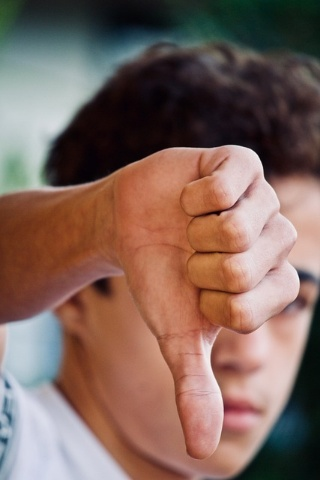

victory.jpg


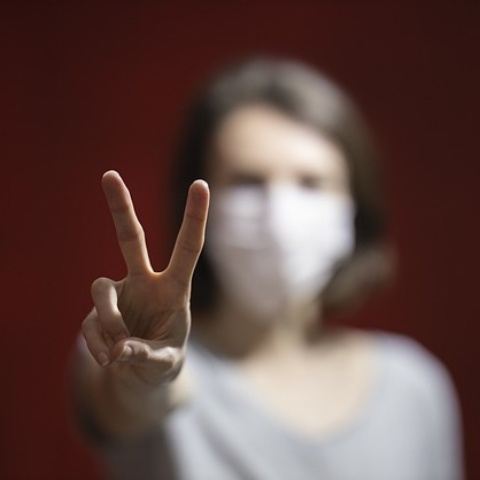

thumbs_up.jpg


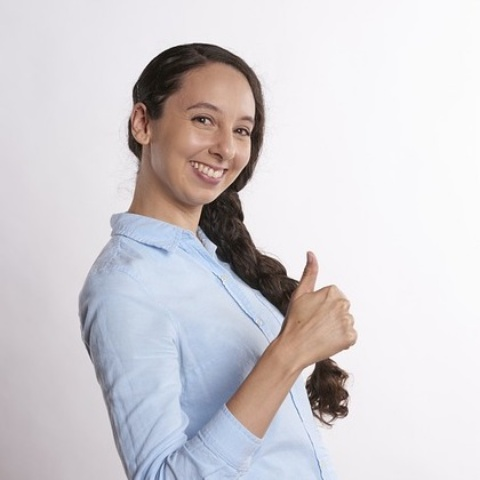

pointing_up.jpg


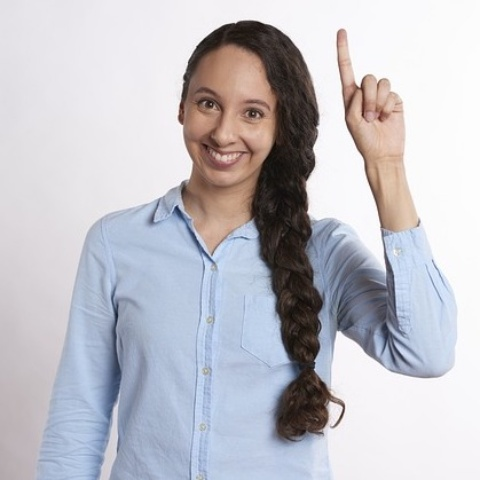

In [8]:
import math

DESIRED_HEIGHT = 480
DESIRED_WIDTH = 480

def resize_and_show(image):
  h, w = image.shape[:2]
  if h < w:
    img = cv2.resize(image, (DESIRED_WIDTH, math.floor(h/(w/DESIRED_WIDTH))))
  else:
    img = cv2.resize(image, (math.floor(w/(h/DESIRED_HEIGHT)), DESIRED_HEIGHT))
  show_image_bgr(img)


# Preview the images.
images = {name: cv2.imread(name) for name in IMAGE_FILENAMES}
for name, image in images.items():
  print(name)
  resize_and_show(image)

## Running inference and visualizing the results

Here are the steps to run gesture recognizer using MediaPipe.

Check out the [MediaPipe documentation](https://developers.google.com/mediapipe/solutions/vision/gesture_recognizer/python) to learn more about configuration options that this solution supports.

*Note: Gesture Recognizer also returns the hand landmark it detects from the image, together with other useful information such as whether the hand(s) detected are left hand or right hand.*

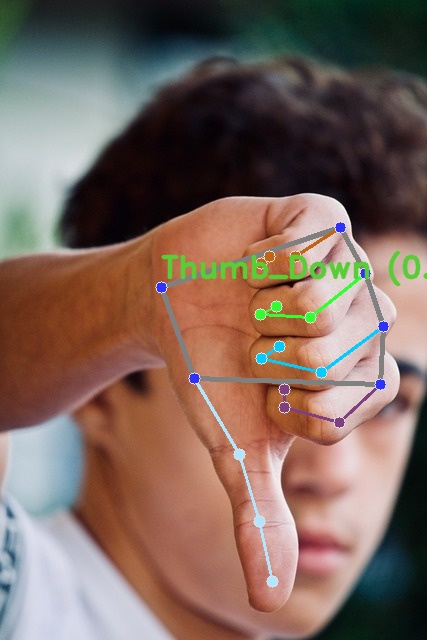

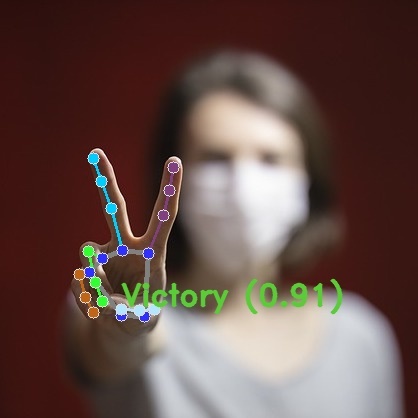

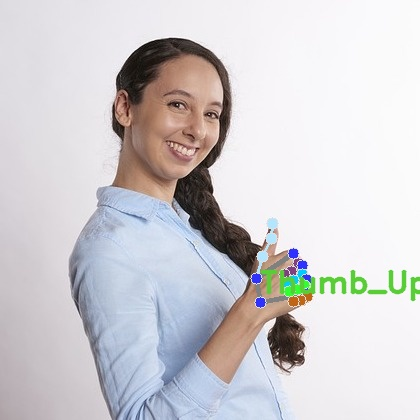

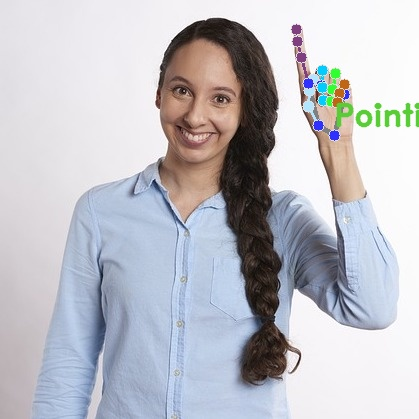

In [9]:
# STEP 1: Import the necessary modules.
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# STEP 2: Create an GestureRecognizer object.
base_options = python.BaseOptions(model_asset_path=str(MODEL_PATH))
options = vision.GestureRecognizerOptions(base_options=base_options)
recognizer = vision.GestureRecognizer.create_from_options(options)

images = []
results = []
for image_file_name in IMAGE_FILENAMES:
  # STEP 3: Load the input image.
  image = mp.Image.create_from_file(image_file_name)

  # STEP 4: Recognize gestures in the input image.
  recognition_result = recognizer.recognize(image)

  # STEP 5: Process the result. In this case, visualize it.
  images.append(image)
  results.append(recognition_result)

display_batch_of_images_with_gestures_and_hand_landmarks(images, results)

In [ ]:
# Webcam demo for local Jupyter use. Press q in the OpenCV window to stop.
import time

camera_index = 0
cap = cv2.VideoCapture(camera_index)
if not cap.isOpened():
    raise RuntimeError(f'Could not open webcam at index {camera_index}. Try 1 if you have multiple cameras.')

base_options = python.BaseOptions(model_asset_path=str(MODEL_PATH))
options = vision.GestureRecognizerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.VIDEO,
    num_hands=4,
    min_hand_detection_confidence=0.5,
    min_hand_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)

with vision.GestureRecognizer.create_from_options(options) as recognizer:
    start_time = time.time()
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            print('Ignoring empty camera frame.')
            continue

        frame = cv2.flip(frame, 1)
        rgb_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
        timestamp_ms = int((time.time() - start_time) * 1000)
        recognition_result = recognizer.recognize_for_video(mp_image, timestamp_ms)

        annotated_frame = draw_recognition_result(frame, recognition_result)
        cv2.imshow('MediaPipe Gesture Recognizer', annotated_frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

cap.release()
cv2.destroyAllWindows()


KeyboardInterrupt: 

: 